# Preparation for GMA of absolute n_TOF $^{235}$U(n,f) cs by Manna using a PPAC (Data release: LA-UR-25-32229)

In [2]:
import os
from importlib import reload
from numpy import array, shape, diag, arange, ones, zeros, loadtxt, sqrt, meshgrid, interp
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
homedir = os.getcwd() +'/'

In [6]:
cd ../../../src

/Users/dneudecker/Documents/Codes/ARIADNE-github/src


In [8]:
import Class_nfcs_legacy as Cnf
reload(Cnf)

<module 'Class_nfcs_legacy' from '/Users/dneudecker/Documents/Codes/ARIADNE-github/src/Class_nfcs_legacy.py'>

Difference between total syst. unc and quadrature: 0.061085972850678516
Difference between total unc and quadrature: 0.034945276469860787


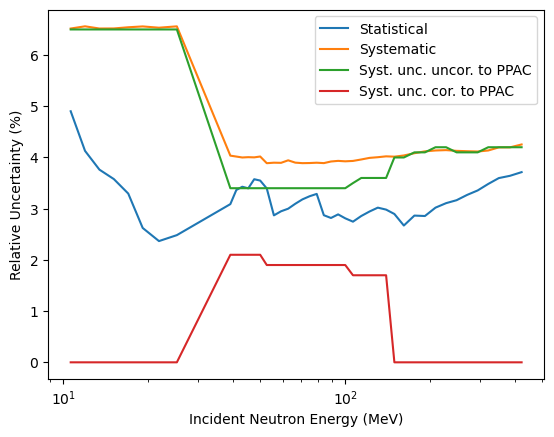

In [10]:
# data were provided in private communication by Naohiko Otsuka after EXFOR compilation. 
datafile = homedir+'MannaPPAC.txt'
alldata  = loadtxt(datafile,comments="#")
Einc = alldata[:,0] 
Ersl = alldata[:,1]*100.0/Einc # half of bin width
Data = alldata[:,2]*1.0e-3 # U-235(n,f) absolute cross section, the data are 
# given relative to the 1-H(n,n) angular distributions at 20 and 25 degree in the CMF
# (R.A.Arndt, Report NEANDC-305p. 39, OECD Nuclear Energy Agency (NEA), 1991).

Totunc = alldata[:,3]*100.0/alldata[:,2]

Statunc = alldata[:,4]*100.0/alldata[:,2] # The statistical uncertainties are given.
# It is unclear if that is only counting statistics for the Pu-9 counts, 
# or includes also background.

TotSystunc = alldata[:,5]*100.0/alldata[:,2] # The total systematic uncertainties are given.

Systunc1 = alldata[:,6] # These are total systematic uncertainties that 
# are not correlated between the PPFC and PPAC exp.

Systunc2 = alldata[:,7] # These are total systematic uncertainties that 
# are correlated between the PPFC and PPAC exp.

plt.semilogx(Einc,Statunc)
plt.semilogx(Einc,TotSystunc)
plt.semilogx(Einc,Systunc1)
plt.semilogx(Einc,Systunc2)
#plt.semilogx(Einc,sqrt(Systunc2**2.0+Systunc1**2.0),'k--')
plt.legend(['Statistical','Systematic','Syst. unc. uncor. to PPAC','Syst. unc. cor. to PPAC'])
plt.xlabel('Incident Neutron Energy (MeV)')
plt.ylabel('Relative Uncertainty (%)')

print('Difference between total syst. unc and quadrature:',max(TotSystunc-sqrt(Systunc2**2.0+Systunc1**2.0)))
print('Difference between total unc and quadrature:',max(Totunc-sqrt(Statunc**2.0+TotSystunc**2.0)))
# I asked Elisa about this difference and she wrote back: "yes, both the difference of 0.05% and 0.075% are due to rounding procedure".
# So, I am not concerned by this difference.

## Comments:
- This is a very well-describe measurement. All effects that I could think of were corrected.
- Given their write-up, I treat the data as absolute without any ratios as they measure relative to 1H(n,n) cs. At the Standards meeting, it was decided: "Denise: to put the 235U(n,f) cs of Manna and Priovano into CRD file as 235U(n,f) absolute cs and put in the CRD file of Manna/ Pirovano what 1H(n,n) angular distributions were used for the Manna/ Pirovano data as tabulated by Naohiko in EXFOR (and angles in the comment). "
- Background could be missing for thermalized neutrons hitting the fission chamber, they do quantify the C-12 background for the monitor measurement and alpha/ gamma background via PSD for their fission chamber measurement. Elisa thinks this should not be an issue because the bunches are separated enough, but I worry more about random coincicdences. It should likely be a small effect in any way. Elisa wrote: "The alpha/gamma discrimination is made with the amplitude spectra, since the FFs and light particle have really different energy deposition in the detector (all confirmed by simulations)." and "We are working in the high energy region and the bunches are well spaced between them, so the thermal neutrons arrive well before the next bunch and do not overlap."
- Forward-boost, angular distriution and stopping power were MC simulated.
- Sample non-uniformity was measured and folded with beam overlap. Seems well-done.
- Multiple scattering seems to be part of background as part of blank measurement. I would add a small uncertainty. Elisa wrote: "We simulated transmission through fission detectors and PE samples.  The estimated uncertainty for this ranges from 0.2% to 0.5%." I added 0.4%.
- Quantified uncertainties: neutron flux, statistics, detector efficiency, normalization, deadtime, impurity. Missing was multiple scattering, which Elisa provided in private communication.

In [12]:
## Uncertainties that are uncorrelated to the PPFC measurement:
normunc_U = 1.0 #% 
deteff_trajectory = 0.4 #%

Edep_systunc1 = sqrt(Systunc1*Systunc1-ones(shape(Einc)[0],dtype='float')*\
                     (normunc_U*normunc_U+deteff_trajectory*deteff_trajectory))

In [14]:
## Uncertainties that are correlated to the PPA\FC measurement:
impurityunc_H = 1.5 #%
beamprofile   = 0.5 #%
beamtranmission = 0.5 #
Edep_systunc2 = zeros(shape(Einc)[0],dtype='float')

for index in arange(0,shape(Einc)[0]):
    if Systunc2[index] > 0:
        Edep_systunc2[index] = sqrt(Systunc2[index]*Systunc2[index]-(impurityunc_H*impurityunc_H+beamprofile*beamprofile+beamtranmission*beamtranmission))

In [16]:
features = {"Author": ["n_TOF collaboration","A.Manna", "E.Pirovano,","et al."],
"Year": "2025",
"Facility": ['SYNCY', 'SPALL', '2ZZZCER'],
"Institute": ["2ZZZCER","2SPNPCM"],
"Isotope": "U-235",
"Quantity": "cs", 'reaction': 'n,f',\
"MeasurementType": "Indirect ratio absolute",
"ConcernEXFOR": "N/A",
"ConcernPARADIGM": ["none"],
"ConcernAIACHNE_text": ["none"],
"BackgroundCorrected": "y",
"AlphaBackground": "y",
"GammaBackground": "y",
"RandomCoincidenceBackground": "N/A",
"ShadowBarBackground": "N/A",
"WrapAroundBackground": "N/A",
"MultipleScatteringSampleBackingCorrected": "y",
"MultipleScatteringSurroundingCorrected": "y",
"AttenuationSampleBackingCorrected": "y",
"AttenuationSurroundingCorrected": "y",
"FissionDetectionEfficiencyCorrected": "y",
"SampleDecayCorrected": "y",
"FissionFragmentAbsorptioninSampleCorrected": "y",
"SignalPulsePileupCorrected": "y",
"DeadtimeCorrected": "y",
"AngularDistributionFissionFragmentsCorrected": "y",
"ForwardBoostCorrected": "y",
"ImpuritiesCorrected": "y",
"CorrelatedData": ["23675.003","23675.004"],
"EXFORnumber": "23675.002",
"Accepted": "y",
"MissingCorrections": ["none"],
"FissionDetector": {
"Type": "PPAC",
"ParticleDetected": "FF",
"Efficiency": ["56-63", "48-56"],'Efficiency_unit':'%',
"EfficiencyMethod": "MC",
"FFAbsorptionAngularDistributionMethod": "MC",
"AngularAcceptaneofFF": "unknown",
"Gas": {"Type": ["C3F8"], "Purity": ["100.0"], "Pressure": 4,"Pressure_unit":"mbar"},
"Size": {"geometry": "cylindrical volumes; 20x20 cm2"},
"NoPhotomultipliers": "N/A",\
"Weight": "unknown",
"StructuralMaterial": ["Mylar","Gold","Cu"],
"ReferenceDetector": "N/A"},
"NeutronDetector": {
"Type": ['TELES','SCIN','SCIN)'],
"Number": [1,1,1],
"ParticleDetected": 'p',
"Efficiency": ["2.25-2.45","2.25-2.45","2.25-2.45"],
"ResponseDeterminationMethod": ["MC","MC"],
"EfficiencyDeterminationMethod": ["MC","MC"],
"Angle": [-25.0,25.0,20.0],
"trsl": {"Value": ["unknown","unknown","unknown"], "Unit": ["ns","ns"], "Measure": "N/A"},
"t0Determination": ["gamma flash","gamma flash","gamma flash"],
"Gas": {"Type": ["unknown","unknown","unknown"], "Purity": ["unknown","unknown","unknown"], "Pressure": ["unknown","unknown"]},
"Size": {"geometry": ["unknown","trapezoid","trapezoid"]},
"NoPhotomultipliers": [3,5,5],
"Photomultipliers": ["Hamamatsu R1924A","Hamamatsu R1924A","Hamamatsu R1924A"],
"Weight": ["unknown","unknown","unknown","unknown"],
"StructuralMaterial": ["teflon","mylar","Al"],
"ReferenceDetector": "N/A",
"ReferenceReaction": '(1-H-1(N,EL)1-H-1,,DA,P)'
},
"Shielding": {"Material": "unknown", "Size": "unknown", "DistanceFromNeutronDetector": "N/A", "Purpose": "unknown"},
"Sample": {"Number":2,
"Activity": 'unknown',
"Activity_unit": "N/A",
"Reused": "no",
"Form": "plate",
"Mass":[263,282], "Mass_unit":'mug/cm2',
"Diameter": [80,80], "Diameter_unit":'mm',
"Thickness": [263,282], "Thickness_unit":'mug/cm2',
"Homogenity": "within 5%",
"Contaminants": {'235U':92.699,'238U':6.283,'234U':0.7472,'236U':0.2696},
"BackingMaterial": "Al",
"BackingDiameter": 80.0,"BackingDiameter_Unit": 'mm',
"BackingThickness": 2.0,'BackingThickness_Unit':'mum',
"DecayDeterminationMethod": "N/A",
"Configuration": "parallel",
"Fabrication": "molecular plated",
"ImpurityDetermination": "mass spectrometry",\
'NumberOfAtomsInSampleDeterminationTechnique':'mass spectrometry'
},
"ShadowBar": {"Used": "n", "Material": "N/A", "Size": "N/A", "Size_unit": "N/A", "Material of structure holding it": "N/A"},
"OutgoingEnergyDetermination": "TOF",
"IndividualChannelWidthDetermination": "unknown",
"AverageChannelWidthDetermination": "Fission peak",
"BackgroundMethods": {
"General": "12C calculated",
"Wraparound": "N/A",
"alpha": "PSD",
"Gamma": "PSD",
"RandomCoincidence": "N/A"
},
"MultipleScatteringMethods": {"InSample": ["measurement (blank)","MC"], "Surrounding": ["measurement (blank)","MC"]},
"AttenuationMethods": {"InSample": ["measurement (blank)","MC"], "Surrounding": ["measurement (blank)","MC"]},
"DeadtimeDeterminationMethod": "Calculated",
'EnergyDetermination':'TOF',
'NeutronBeam':{'Facility':['SYNCY', 'SPALL', '2ZZZCER'],'PulseWidth':7,'PulseWidthUnit':'ns',
               'NeutronProducingReaction':'p,Pb','Target':'Pb',
               'EnergySpread':' high energy resolution Delta 𝐸∕𝐸 that ranges from e10−4 at thermal energy to e10−2 in the hundreds of MeV',
'Monitor':'1H(n,n)',
'Diameter':2.0,'Diameter_unit':'cm','TimeGateOpen':'N/A','TimeGateOpen_unit':'N/A',
"TOFLength": {"Value": 185. , "Unit": "m", "Unc": 0.01,"Unc_Unit":'m'},\
'trsl':{'Value':'unknown','Unit':'ns','Measure':'N/A'},\
't0Determination':'gamma flash'}        
}



In [18]:
# ------------------------------------------------------------------
attenuation_multscatt_unc = 0.4*ones(shape(Einc)[0],dtype = float)
# --------------------------------------------------------------------

# From Sanchez-Caballero measurement ---------------------------------
TOFlength = 185.0 # m
TOFlength_unc = 0.0 # m
# --------------------------------------------------------------------

Testing covariance matrix of type Positive_fully:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Diagonal:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

{'isotope': 'U-235', 'quantity': 'cs', 'reaction': 'n,f', 'identifier': 'ENDF/B-VIII.0'}
Testing enerr covariance matrix:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing enrsl covariance matrix:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing cov_eunc covariance matrix:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing total covariance matrix:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

WIP: not yet included. No Xml file produced.

Output file saved in file: /Users/dn

/Users/dneudecker/Documents/Codes/ARIADNE-github/src/BasicPhysicsFunctions.py:230: RuntimeWarning: divide by zero encountered in scalar divide
  data_derivative[index] = (data[index+1]-data[index])/(lattice[1+index]-lattice[index])
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


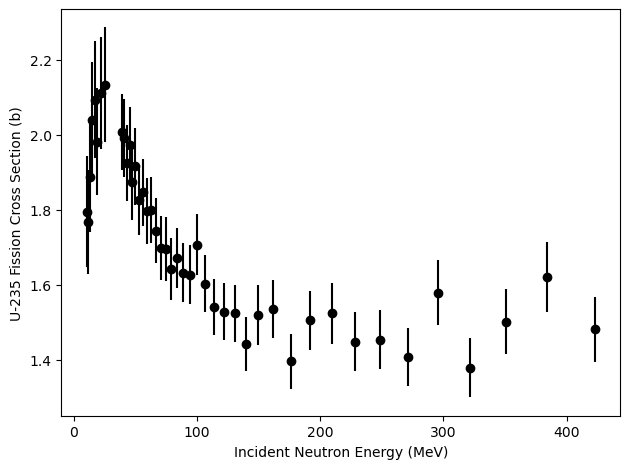

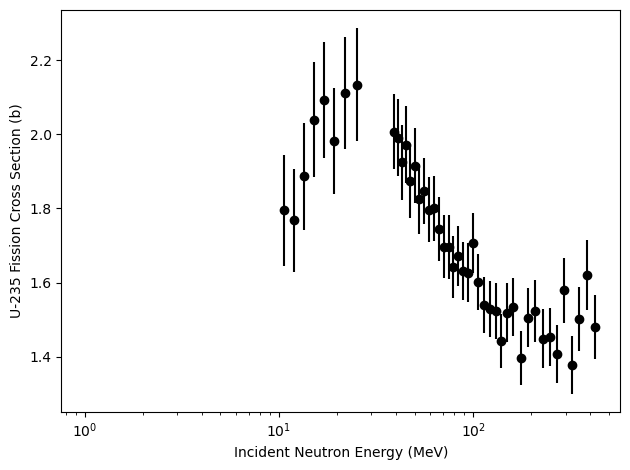

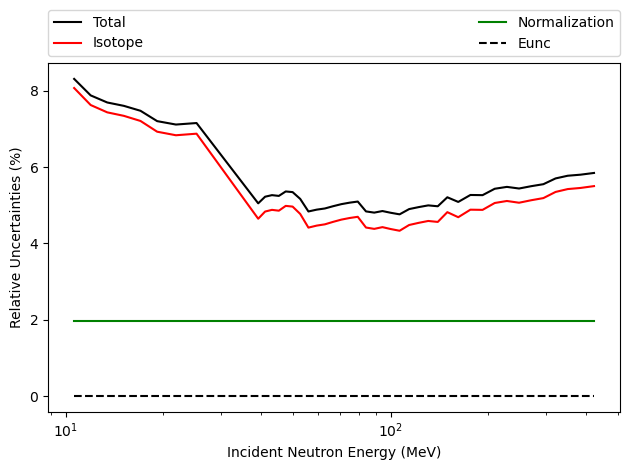

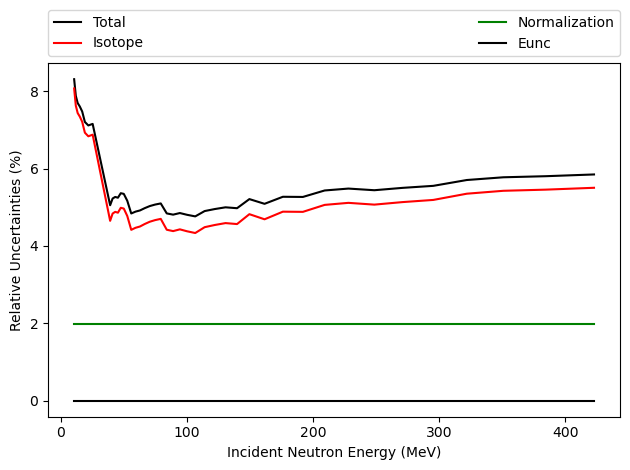

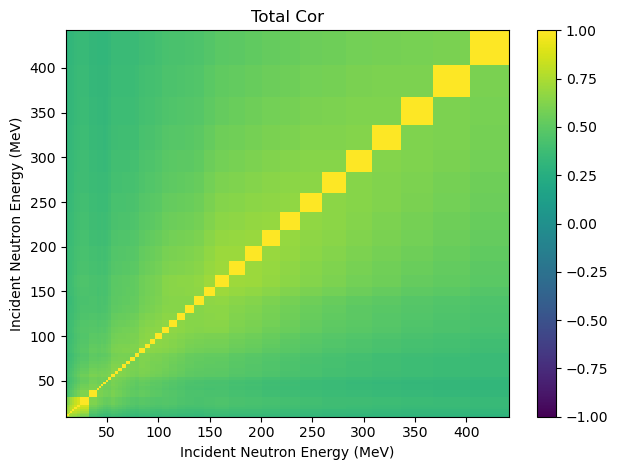

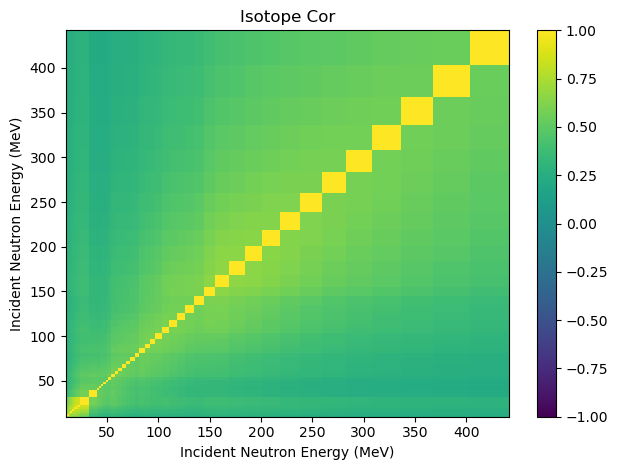

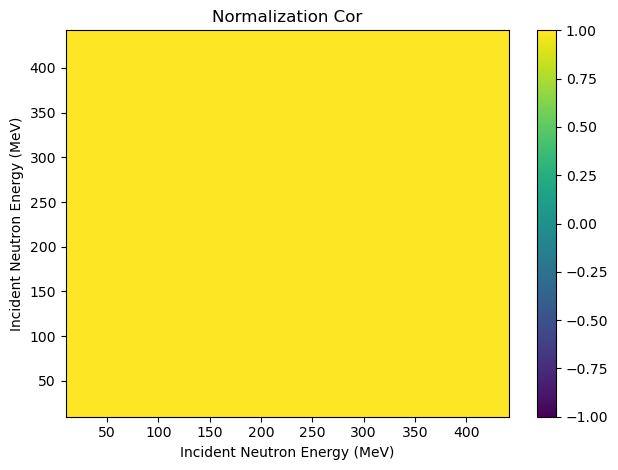

/Users/dneudecker/Documents/Codes/ARIADNE-github/src/MatrixFunctions.py:44: RuntimeWarning: invalid value encountered in scalar divide
  cor[index1,index2] = cov[index1,index2]/\


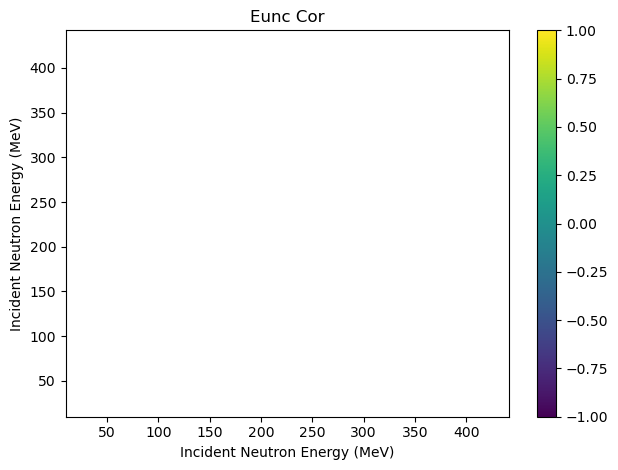

In [22]:
Documentation = """EXFOR No. = 23675.002; Journal article = A. Manna et al. Physics Letters B 860 (2025) 139213.
- This is a very well-describe measurement. All effects that I could think of were corrected.
- Given their write-up, I treat the data as absolute without any ratios as they measure relative to 1H(n,n) cs. At the Standards meeting, it was decided: "Denise: to put the 235U(n,f) cs of Manna and Priovano into CRD file as 235U(n,f) absolute cs and put in the CRD file of Manna/ Pirovano what 1H(n,n) angular distributions were used for the Manna/ Pirovano data as tabulated by Naohiko in EXFOR (and angles in the comment). "
- Background could be missing for thermalized neutrons hitting the fission chamber, they do quantify the C-12 background for the monitor measurement and alpha/ gamma background via PSD for their fission chamber measurement. Elisa thinks this should not be an issue because the bunches are separated enough, but I worry more about random coincicdences. It should likely be a small effect in any way. Elisa wrote: "The alpha/gamma discrimination is made with the amplitude spectra, since the FFs and light particle have really different energy deposition in the detector (all confirmed by simulations)." and "We are working in the high energy region and the bunches are well spaced between them, so the thermal neutrons arrive well before the next bunch and do not overlap."
- Forward-boost, angular distriution and stopping power were MC simulated.
- Sample non-uniformity was measured and folded with beam overlap. Seems well-done.
- Multiple scattering seems to be part of background as part of blank measurement. I would add a small uncertainty. Elisa wrote: "We simulated transmission through fission detectors and PE samples.  The estimated uncertainty for this ranges from 0.2% to 0.5%." I added 0.4%.
- Quantified uncertainties: neutron flux, statistics, detector efficiency, normalization, deadtime, impurity. Missing was multiple scattering, which Elisa provided in private communication."""


general_info = {'name': 'DS6009', 'isotope': 'U-235', 'quantity': 'cs', 'reaction': 'n,f', \
                'output_file' : homedir+'DS6009.xml', \
                'output_folder' : homedir,\
                'documentation' : Documentation}

einc_unc = {'tof_length': {'value':  TOFlength ,'value_unit': 'm', \
                           'unc': TOFlength_unc,'unc_unit': 'm'}, \
            'identifier_iso_deriv1' : 'ENDF/B-VIII.0'}

normunc_U = 1.0 #% 
deteff_trajectory = 0.4 #%
impurityunc_H = 1.5 #%
beamprofile   = 0.5 #%
beamtranmission = 0.5 #

normunc = sqrt(normunc_U*normunc_U+deteff_trajectory*deteff_trajectory+impurityunc_H*impurityunc_H+beamprofile*beamprofile+\
              beamtranmission*beamtranmission)

norm_unc = {'value': normunc, 'unit':'%'}

unc_iso = {'einc_unc': einc_unc, 'normalization_unc':norm_unc, \
           'values':array([Statunc,Edep_systunc1,\
                           Edep_systunc2]).transpose(),\
           'units':['%','%','%'],\
           'type':['Diagonal','Gaussian','Gaussian'],\
            'type_arg':{'einc':array(Einc),'damp_term':[1.0,1.0,1.0]}}

data = {'einc': array(Einc), 'einc_unit': 'MeV', 'values':array(Data), 'values_unit': "b" }

DS6009_nfcs = Cnf.nfcs_absolute(general_info,data,unc_iso,features)

In [24]:
GMAnewnumber='6009'
year = '2025'
authors = 'Manna (n_TOF)'
journal = 'J,PLB,860(2025)'

dim = shape(Einc)[0]        

normalizationunc = [normunc_U,deteff_trajectory,0.0,0.0,0.0,impurityunc_H,beamprofile,beamtranmission,0.0,0.0]

uncertainty_descriptor = ['UNCERTAINTIES','1 Normal. unc.: sample mass, reconstruction of FF trjectories',\
                          'empty, empty, empty, impurity (H), beam profile, beam transmission',\
                          '2 Energy resl explicitly given in EXFOR',\
                          '3 Statistical Unc.','4 Energy dependent syst. unc. (uncorrelated to Pirovano PPFC)',\
                          '5 Energy dependent syst. unc. (correlated to Pirovano PPAC)',\
                          '6 Multiple scatt. and attenuation unc.',
                         'MONITOR  1-H-1(N,EL)1-H-1,,DA,P by  R.A.Arndt,S,NEANDC-305,39,1991',\
                          'n-p scattering cross section in the centre-of-mass',\
                          'system for proton at 20 and 25 deg in the laboratory',\
                          'system in LA150 library (VL40 wave analysis energy',\
                          'dependent phase-shift solution of Arndt above 26 MeV)',\
                          'interpolated by MCNP',\
                          'Tlab (MeV)  sigma,cm (mb/srm) 20.0 deg 25.0 deg',\
                          '20.0           151.1773             143.0919',\
                          '25.0           119.6774             112.3854',\
                          '30.0            98.2831              91.4940',\
                          '35.0            82.9424              76.5152',\
                          '40.0            71.5839              65.3763',\
                          '45.0            62.8253              56.8485',\
                          '50.0            55.9827              50.1418',\
                          '55.0            50.5020              44.8111',\
                          '60.0            46.0731              40.4603',\
                          '65.0            42.4019              36.9134',\
                          '70.0            39.3703              33.9688',\
                          '75.0            36.8074              31.5020',\
                          '80.0            34.6420              29.4214',\
                          '85.0            32.7947              27.6482',\
                          '90.0            31.2097              26.1335',\
                          '95.0            29.8372              24.8245',\
                          '100.0            28.6440              23.6949',\
                          '110.0            26.6841              21.8386',\
                          '120.0            25.1544              20.3961',\
                          '130.0            23.9333              19.2479',\
                          '140.0            22.9368              18.3085',\
                          '150.0            22.1063              17.5243',\
                          '160.0            21.3968              16.8537',\
                          '170.0            20.7786              16.2632',\
                          '180.0            20.2285              15.7369',\
                          '190.0            19.7309              15.2568',\
                          '200.0            19.2700              14.8089',\
                          '210.0            18.8391              14.3918',\
                          '220.0            18.4333              13.9956',\
                          '230.0            18.0407              13.6170',\
                          '240.0            17.6676              13.2522',\
                          '250.0            17.3040              12.8977',\
                          '260.0            16.9518              12.5551',\
                          '270.0            16.6048              12.2189',\
                          '280.0            16.2674              11.8915',\
                          '290.0            15.9355              11.5723',\
                          '300.0            15.6067              11.2609',\
                          '310.0            15.2859              10.9539',\
                          '320.0            14.9683              10.6510',\
                          '330.0            14.6563              10.3578',\
                          '340.0            14.3475              10.0676',\
                          '350.0            14.0429               9.7806' ]
abc_components = ones([11,3],dtype=float)*0.5
abc_components[0,:] = [0.99, 0.01,0.5]
abc_components[1:3,:] = zeros([2,3],dtype=float)
abc_components[3,:] = [0.1, 0.9,0.01]
abc_components[4,:] = [0.0, 1.0,0.01]
abc_components[5,:] = [0.99,0.01,0.5]

uncertainties = zeros([dim,12],dtype=float)
uncertainties[:,:4] = array([Statunc,Edep_systunc1,\
                           Edep_systunc2,attenuation_multscatt_unc]).transpose()

controlnumber = [0,0,9,1,1,1,0,0,0,0,0]

data = {'einc': Einc, 'einc_unit': 'MeV', 'values':Data, 'values_unit': "none" }
Enrsl = Ersl
Eunc = zeros(dim,dtype=float)
abs_shape = 'absolute'
reference = 'none'

In [28]:
import WriteGMAOutput as WGMA
output = WGMA.WriteGMAOutput(GMAnewnumber,year,authors,journal,general_info,uncertainty_descriptor,data,reference,\
                     abs_shape,abc_components,Eunc,Enrsl,uncertainties,controlnumber,normalizationunc)

5
5
5
5
5
5
5
5
5
5
